### Data-driven road safety policy analysis system

 This project focuses on the use of historical accident data from the workshop to identify patterns and predict road accidents and injury severity. It applies data preprocessing and machine learning models to support the Department for Transport in understanding when, where, and why accidents occur.

The goal is to improve road safety by enabling data-informed decisions and targeted interventions such as better road design, enforcement, and policy changes.


#### Creating Function for Data Base connection


A database connector is used to establish a connection between Python and the database, enabling efficient data retrieval and manipulation through SQL queries.

In [1]:
# IMPORTING  LIB.

import sqlite3
import pandas as pd
import numpy as np, matplotlib.pyplot as plt, seaborn as sns

# CREATING CONNECTION CLASS
class DatabaseConnector:
    def __init__(self, db_path):
        self.db_path = db_path
        self.connection = None

    def connect(self):
        self.connection = sqlite3.connect(self.db_path)
        return self.connection

    def close(self):
        if self.connection:
            self.connection.close()

In [2]:
# CONNECT
db = DatabaseConnector("accident_data_v1.0.0_2023.db")
con = db.connect()


In [3]:
print(con)

In [4]:

# INSPECTING THE DATA COLUMNS
cursor = con.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print(cursor.fetchall())

[('accident',), ('casualty',), ('vehicle',), ('lsoa',)]


### Data Loading Functions and Classes

Defines reusable functions and classes to load data from the database into structured DataFrames. This centralises the data access process, ensures consistency across all tables, and reduces code duplication.

It also improves code organisation, making the data pipeline easier to maintain, extend, and debug.le functions and classes to load data from the database into structured DataFrames, ensuring consistent data access while reducing code duplication.


In [5]:
class DataLoader:
    def __init__(self, connection):
        self.con = connection

    def load_accidents(self):
        query = "SELECT * FROM accident"
        return pd.read_sql(query, self.con)

    def load_vehicles(self):
        query = "SELECT * FROM vehicle"
        return pd.read_sql(query, self.con)

    def load_casualties(self):
        query = "SELECT * FROM casualty"
        return pd.read_sql(query, self.con)

    def load_lsoa(self):
        query = "SELECT * FROM lsoa"
        return pd.read_sql(query, self.con)

In [6]:
# Loading the data accross mutiple table
loader = DataLoader(con)
accidents = loader.load_accidents()
vehicles = loader.load_vehicles()
casualties = loader.load_casualties()


### Preprocessing Functions and Classes

Implementing functions and classes to clean and prepare the data, including handling missing values set at (-1) for missing vaules, merging tables, encoding categorical variables, and creating new features. This ensures the dataset is structured and suitable for modelling.

By organising preprocessing into reusable components, the pipeline remains consistent, easier to manage, and adaptable to changes in the data.

In [7]:
class Preprocessor:
    def __init__(self, df):
        self.df = df

    def clean_data(self):
        self.df.replace(-1, np.nan, inplace=True)
        return self.df

    def create_time_features(self):
        if 'date' in self.df.columns:
            self.df['date'] = pd.to_datetime(self.df['date'], format='%d/%m/%Y')
            self.df['day'] = self.df['date'].dt.day_name()

        if 'time' in self.df.columns:
            self.df['time'] = pd.to_datetime(self.df['time'], format='%H:%M', errors='coerce')
            self.df['hour'] = self.df['time'].dt.hour

        return self.df

    def classify_motorcycle(self, df_vehicle):
        def classify(cc):
            if pd.isna(cc):
                return np.nan
            elif cc <= 125:
                return "≤125cc"
            elif cc <= 500:
                return "125–500cc"
            else:
                return ">500cc"

        df_vehicle['bike_category'] = df_vehicle['engine_capacity_cc'].apply(classify)
        return df_vehicle

In [8]:
# Executing preprocessing functions
prep = Preprocessor(accidents)
accidents = prep.clean_data()
accidents = prep.create_time_features()

vehicles = prep.classify_motorcycle(vehicles)


### Accident Analysis Class and functions

This invoulues methods for exploring and analysing accident data, including summarising key patterns, filtering by conditions, and extracting insights from variables such as weather, location, vehicles, and casualties.

It provides a structured and reusable way to perform analysis, making the workflow more organised and easier to extend for further investigation.

In [9]:


class AccidentAnalysis:
    def __init__(self, df):
        self.df = df

    
    # ACCIDENTS BY HOUR
    
    def accidents_by_hour(self):
        result = self.df.groupby('hour').size()

        result.plot(kind='bar', figsize=(10,5))
        plt.title("Accidents by Hour")
        plt.xlabel("Hour")
        plt.ylabel("Number of Accidents")

        plt.savefig("Accidents_by_Hour.png", dpi=200, bbox_inches="tight")
        plt.show()

        return result

    
    # ACCIDENTS BY DAY
    
    def accidents_by_day(self):
        result = self.df.groupby('day').size()

        result.plot(kind='bar', figsize=(10,5))
        plt.title("Accidents by Day")
        plt.xlabel("Day of Week")
        plt.ylabel("Number of Accidents")

        plt.savefig("Accidents_by_Day.png", dpi=200, bbox_inches="tight")
        plt.show()

        return result

    
    # HEATMAP  AND INSIGHT MAX ACCIDENT
    
    def heatmap_hour_day(self):
        pivot = pd.crosstab(self.df['hour'], self.df['day'])

        plt.figure(figsize=(10,6))
        sns.heatmap(pivot, cmap="YlOrRd")

        plt.title("Heatmap: Hour vs Day")
        plt.xlabel("Day of Week")
        plt.ylabel("Hour of Day")

        plt.savefig("Heatmap_Hour_Day.png", dpi=200, bbox_inches="tight")
        plt.show()

        #  Peak insight
        max_value = pivot.values.max()
        max_hour, max_day = pivot.stack().idxmax()

        insight = (
            f"The highest number of accidents occurs on {max_day} "
            f"at {max_hour}:00 with {max_value} incidents."
        )

        print(insight)

        return pivot, insight

    
    # MOTORCYCLE ANALYSIS

    def motorcycle_analysis(self, df_vehicle):

        df = self.df.merge(df_vehicle, on='accident_index', how='inner')

        # Prefer preprocessed feature
        if 'bike_category' in df.columns:
            bikes = df.dropna(subset=['bike_category'])
            group_col = 'bike_category'
        else:
            bikes = df[df['vehicle_type'].isin([2, 3, 4])]
            group_col = 'vehicle_type'

        result = bikes.groupby([group_col, 'hour']).size().unstack(fill_value=0)

        result = result.sort_index(axis=1)

        result.plot(kind='bar', stacked=True, figsize=(10,6))

        plt.title("Motorcycle Accidents by Category & Hour")
        plt.xlabel("Category")
        plt.ylabel("Number of Accidents")

        plt.xticks(rotation=45)

        plt.savefig("Motorcycle_Accidents.png", dpi=200, bbox_inches="tight")
        plt.show()

        return result

    
    # PEDESTRIAN ANALYSIS 
  
    def pedestrian_analysis(self, df_casualty):

        df = self.df.merge(df_casualty, on='accident_index', how='inner')

        #  UK dataset coding (pedestrian = 0)
        pedestrians = df[df['casualty_type'] == 0]

        if pedestrians.empty:
            print("No pedestrian data found. Check casualty_type encoding.")
            return None

        result = pedestrians.groupby(['hour', 'day']).size().unstack(fill_value=0)

        result.plot(kind='bar', stacked=True, figsize=(10,6))

        plt.title("Pedestrian Accidents by Hour & Day")
        plt.xlabel("Hour")
        plt.ylabel("Number of Accidents")

        plt.xticks(rotation=45)

        plt.savefig("Pedestrian_Accidents.png", dpi=200, bbox_inches="tight")
        plt.show()

        return result

### Visualization For Accidents 
This visuals displays accidents by Hour, by day and a heatmap comparing hour and day simutanously 

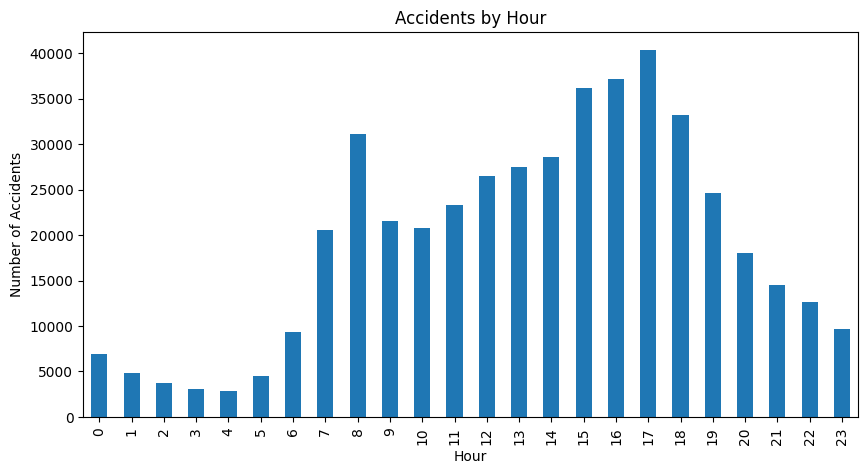

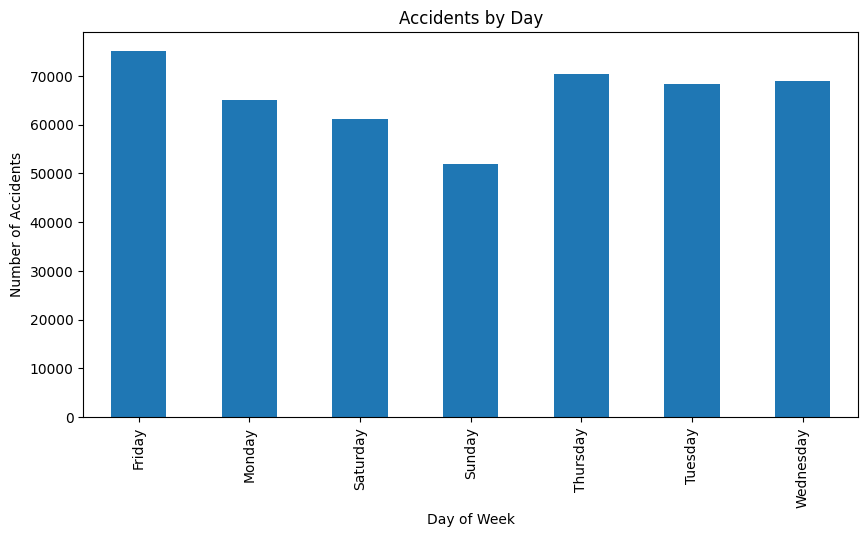

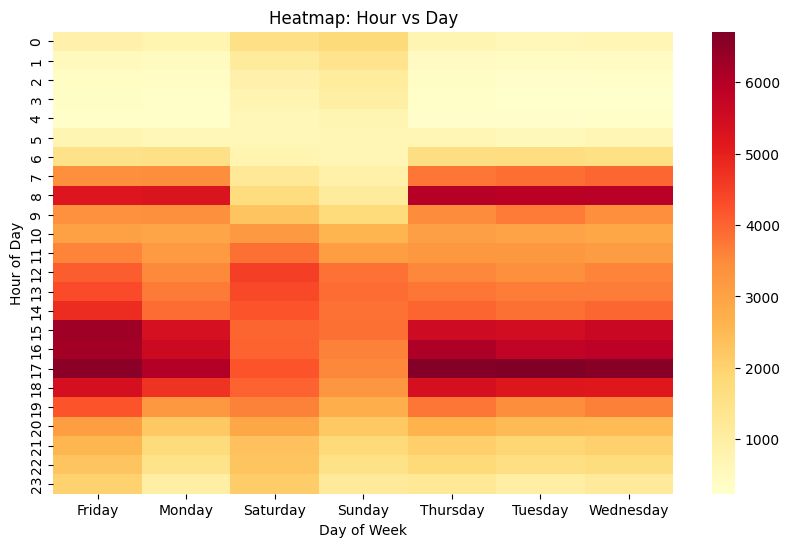

The highest number of accidents occurs on Tuesday at 17:00 with 6709 incidents.


(day   Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
 hour                                                                
 0        854     757      1538    1793       692      603        646
 1        527     481      1146    1413       451      413        430
 2        398     375       849    1107       347      281        328
 3        344     312       733     944       290      236        256
 4        321     299       631     716       286      272        308
 5        697     630       629     660       652      560        646
 6       1494    1529       763     691      1650     1664       1571
 7       3444    3472      1205     879      3774     3856       3973
 8       5222    5285      1695    1136      5976     5911       5927
 9       3395    3414      2307    1763      3491     3702       3445
 10      3049    2924      3200    2594      3078     2972       2902
 11      3586    3188      3845    3112      3262     3242       3121
 12      4089    351

In [10]:
# ANALYSIS 
analysis = AccidentAnalysis(accidents)   # creating an object
analysis.accidents_by_hour()             # executing the function
analysis.accidents_by_day()
analysis.heatmap_hour_day()


### Motor Cycle Analysis

Focuses on analysing accident data involving motorcycles, including frequency, severity, and contributing factors such as road conditions, weather, and rider characteristics.

It helps identify patterns specific to motorcycle-related accidents to support targeted safety insights and risk reduction strategies.

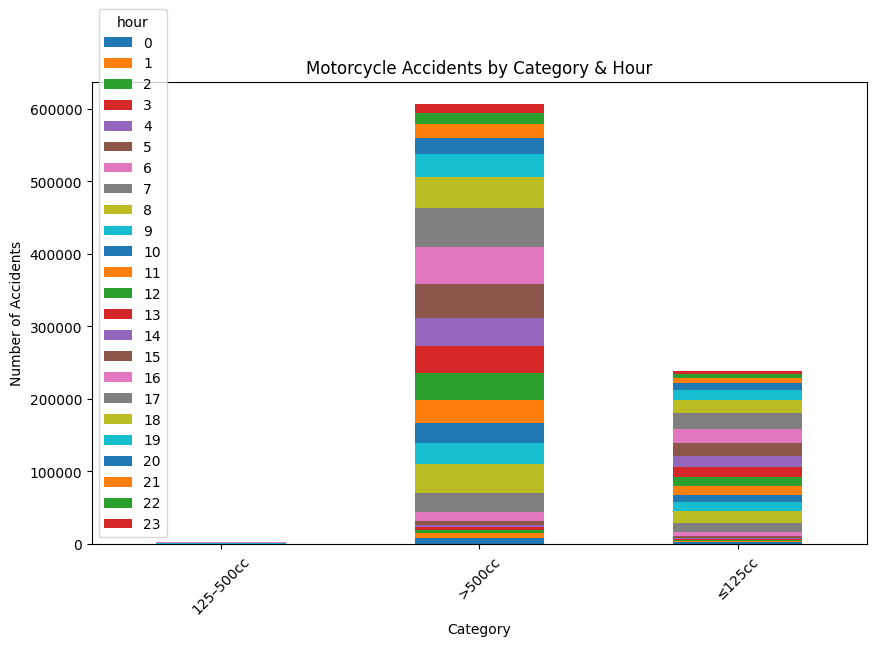

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
bike_category,,,,,,,,,,,,,,,,,,,,,
125–500cc,20,18,14,3,11,35,61,180,200,140,...,244,259,276,365,257,160,105,89,58,36
>500cc,8620,6099,4574,3787,3487,5524,11841,26740,40018,28617,...,38857,47066,50016,54273,43000,31230,22574,18420,16043,12151
≤125cc,2840,1871,1348,1133,1171,2332,5501,12254,17437,11433,...,14391,17861,19357,21814,18446,13345,9656,7342,6107,4266


In [11]:
analysis.motorcycle_analysis(vehicles)

### Pedestrian Analysis

Focuses on analysing accidents involving pedestrians, including their frequency, severity, and associated factors such as crossing type, location, and environmental conditions.

It helps identify high-risk scenarios for pedestrians to support targeted road safety improvements.

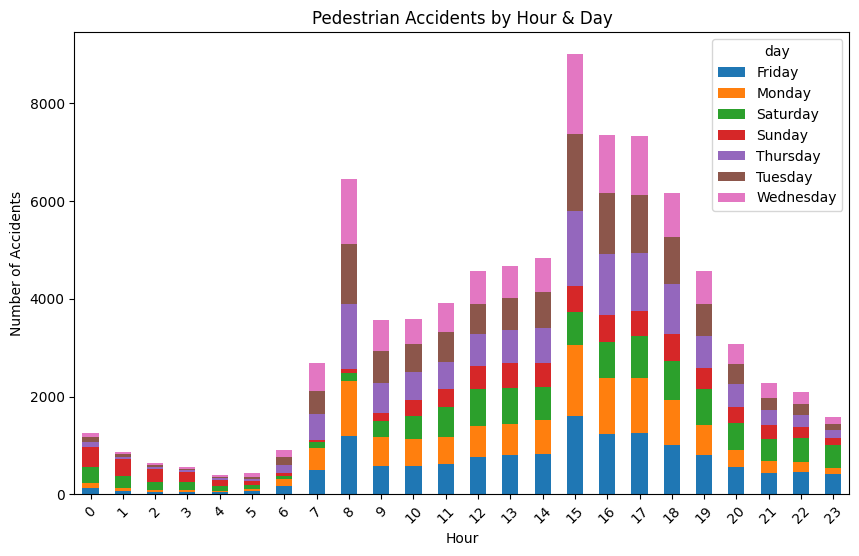

day,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
hour,,,,,,,
0,131,100,317,428,100,96,82
1,61,71,235,353,46,50,46
2,45,45,167,260,42,37,47
3,51,44,166,192,45,20,31
4,43,32,93,126,37,31,29
5,61,53,78,80,50,40,66
6,166,151,62,63,154,171,147
7,491,463,110,51,520,488,557
8,1186,1127,174,83,1313,1231,1334


In [12]:
analysis.pedestrian_analysis(casualties)

### Apriori Class

Implements the Apriori algorithm to discover frequent patterns and association rules within the accident dataset, identifying relationships between variables such as weather, road conditions, and accident severity.

It helps uncover hidden co-occurrence patterns that can support data-driven insights for accident prevention strategies.

In [13]:
from mlxtend.frequent_patterns import apriori, association_rules

class AprioriAnalysis:
    def __init__(self, df):
        self.df = df

    def prepare_data(self):
        cols = ['weather_conditions', 'light_conditions', 
                'road_surface_conditions', 'accident_severity']
        df = self.df[cols].dropna()

        return pd.get_dummies(df.astype(str))

    def run_apriori(self, min_support=0.05):
        df_encoded = self.prepare_data()
        frequent = apriori(df_encoded, min_support=min_support, use_colnames=True)
        rules = association_rules(frequent, metric="lift", min_threshold=1)
        return rules

In [14]:
ap = AprioriAnalysis(accidents)
rules = ap.run_apriori()

print(rules.head(5))

                                antecedents  \
0       frozenset({weather_conditions_1.0})   
1         frozenset({light_conditions_1.0})   
2       frozenset({weather_conditions_1.0})   
3  frozenset({road_surface_conditions_1.0})   
4       frozenset({weather_conditions_1.0})   

                                consequents  antecedent support  \
0         frozenset({light_conditions_1.0})            0.796435   
1       frozenset({weather_conditions_1.0})            0.713303   
2  frozenset({road_surface_conditions_1.0})            0.796435   
3       frozenset({weather_conditions_1.0})            0.712953   
4          frozenset({accident_severity_2})            0.796435   

   consequent support   support  confidence      lift  representativity  \
0            0.713303  0.596341    0.748763  1.049713               1.0   
1            0.796435  0.596341    0.836028  1.049713               1.0   
2            0.712953  0.674533    0.846940  1.187933               1.0   
3            0

### Clustering

Applies clustering techniques to group accident records based on similarity in features such as location, conditions, and severity, without using predefined labels.

It helps reveal natural patterns in the data and identify high-risk groups or regions for further analysis.

In [15]:
from sklearn.cluster import KMeans

class ClusteringAnalysis:
    def __init__(self, df):
        self.df = df

    def filter_hull(self):
        return self.df[self.df['lsoa_of_accident_location'].str.contains("E06", na=False)]

    def run_kmeans(self, k=5):
        data = self.df[['latitude', 'longitude']].dropna()
        model = KMeans(n_clusters=k)
        data['cluster'] = model.fit_predict(data)

        plt.scatter(data['longitude'], data['latitude'], c=data['cluster'])
        plt.title("Accident Clusters")
        plt.savefig("Accident Clusters.png", dpi=200, bbox_inches='tight')
        plt.show()

        return data

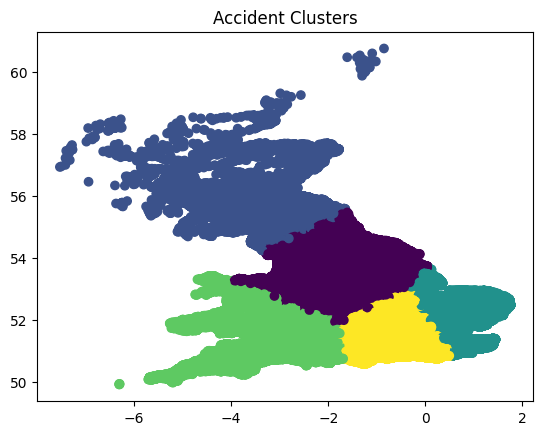

,latitude,longitude,cluster
0,51.650061,-0.080107,4
1,51.522425,-0.173845,4
2,51.514096,-0.052969,4
3,51.624832,-0.060658,4
4,51.573408,-0.072372,4
...,...,...,...
461347,56.473539,-2.926320,1
461348,55.802353,-4.267565,1
461349,57.186317,-2.271903,1
461350,55.950940,-3.968753,1


In [16]:
cluster = ClusteringAnalysis(accidents)
cluster.run_kmeans()

### Time Series Analysis

Analyses accident trends over time by examining patterns across hours, days, months, or years to identify seasonal effects and peak accident periods.

It helps understand how accident frequency changes over time and supports forecasting and planning of road safety interventions.

In [17]:

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

class TimeSeriesAnalysis:

    def __init__(self, df):
        self.df = df.copy()

    
    # PREPARE WEEKLY SERIES (FOR POLICE FORCE - Q1)
    
    def prepare_weekly_series(self, police_force):
        df = self.df[self.df['police_force'] == police_force].copy()

        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')

        weekly = df.resample('W').size()
        return weekly

    
    # ARIMA MODEL FOR Q6
    
    def train_arima_police_force(self, series, police_force):

        # Train-test split
        train = series['2017':'2018']
        test = series['2019']

        model = ARIMA(train, order=(1,1,1)).fit()
        forecast = model.forecast(steps=len(test))

        # Evaluation
        rmse = np.sqrt(mean_squared_error(test, forecast))

        # Plot
        plt.figure(figsize=(10,5))
        plt.plot(test.index, test, label="Actual")
        plt.plot(test.index, forecast, label="Forecast")
        plt.title(f"ARIMA Forecast - Police Force {police_force}")
        plt.legend()
        plt.savefig(f"ARIMA_{police_force}.png", dpi=200, bbox_inches='tight')
        plt.show()

        print(f"Police Force {police_force} RMSE: {rmse}")

        return forecast, rmse

    
    # Q6 PIPELINE: RUN FOR 3 POLICE FORCES
    
    def run_police_force_analysis(self, police_forces):

        results = {}

        for pf in police_forces:
            series = self.prepare_weekly_series(pf)
            forecast, rmse = self.train_arima_police_force(series, pf)

            results[pf] = {
                "forecast": forecast,
                "rmse": rmse
            }

        return results

    
    # Q7: LSOA DAILY FORECASTING PIPELINE
    

    def lsoa_forecasting(self, hull_code=32.0):
    
        df = self.df.copy()
    
        
        # CLEAN DATE
        
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date'])
    
        #
        # FILTER HULL (NUMERIC CODE)
    
        df = df[df['local_authority_district'] == hull_code]
    
        if df.empty:
            print("No data found for Hull code:", hull_code)
            return None
    
        # FILTER 2019
        
        df_2019 = df[df['date'].dt.year == 2019]
    
        if df_2019.empty:
            print("No 2019 data found for Hull code:", hull_code)
            return None
    
    
        
        # TOP 30 LSOAs (Jan–Mar 2019)
        
        q1 = df_2019[df_2019['date'].dt.month.isin([1, 2, 3])]
    
        top30_lsoa = (
            q1.groupby('lsoa_of_accident_location')
            .size()
            .sort_values(ascending=False)
            .head(30)
            .index
        )
    
        
        # FILTERING THE TOP 30 LSOAs
        
        df_top30 = df_2019[df_2019['lsoa_of_accident_location'].isin(top30_lsoa)]
    
        if df_top30.empty:
            print("No LSOA data found after filtering top 30.")
            return None
    
        
        # DAILY TIME SERIES
        
        df_top30 = df_top30.set_index('date')
    
        daily_series = df_top30.resample('D').size()
    
        if len(daily_series) < 10:
            print("Not enough data for ARIMA model.")
            return None
    
        
        # TRAINING THE MODEL (JAN–JUN 2019)
        
        train = daily_series['2019-01':'2019-06']
    
        if len(train) < 10:
            print("Training data too small for ARIMA.")
            return None
    
        model = ARIMA(train, order=(1, 1, 1)).fit()
    
        
        #  JULY (31 DAYS) AS FORCAST 
        
        forecast = model.forecast(steps=31)
    
        
        # VISUAL PLOTTING
        
        plt.figure(figsize=(10, 5))
        plt.plot(train.index, train, label="Train (Jan–Jun)")
        plt.plot(pd.date_range(start=train.index[-1], periods=31, freq='D'),
                 forecast,
                 label="Forecast (July)")
    
        plt.title("Hull LSOA Daily Accident Forecast (Top 30 Areas)")
        plt.legend()
        plt.xticks(rotation=45)
    
        plt.savefig("Hull_LSOA_Forecast.png", dpi=200, bbox_inches='tight')
        plt.show()
    
        return forecast

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


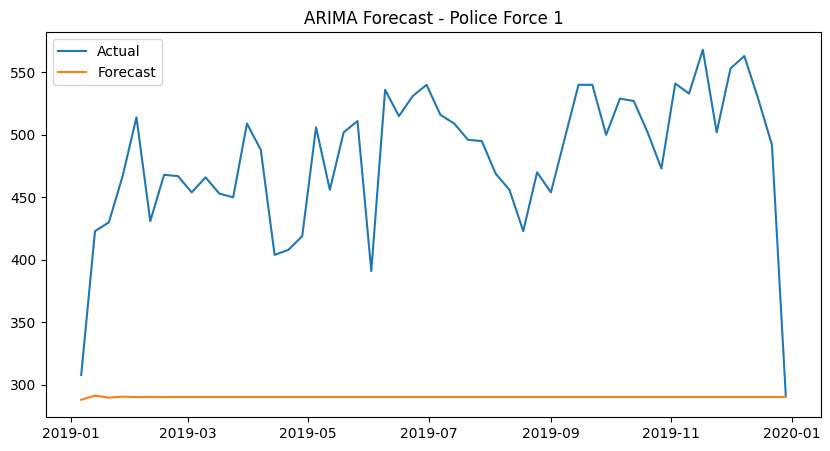

Police Force 1 RMSE: 198.7790704678904


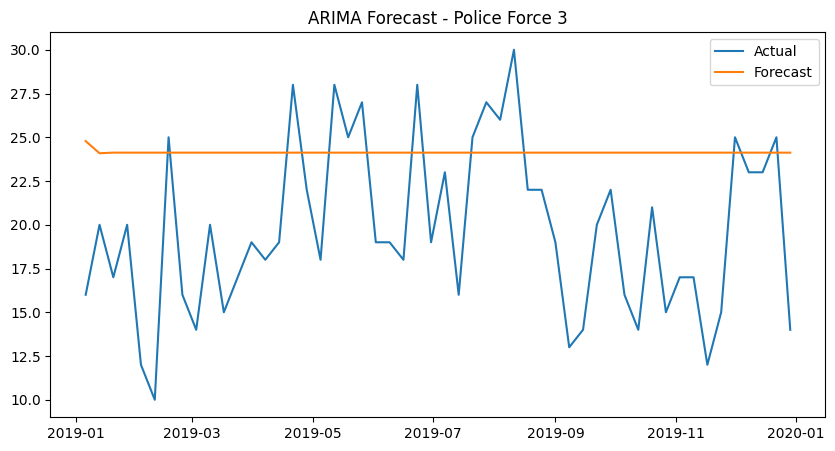

Police Force 3 RMSE: 6.544000008628538


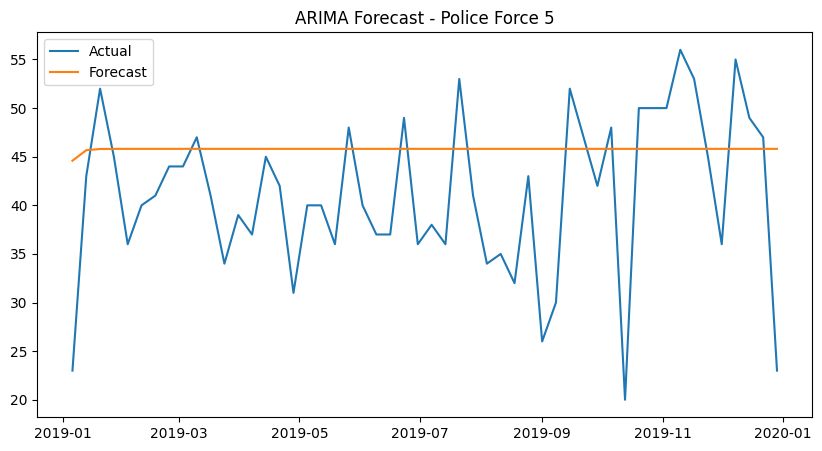

Police Force 5 RMSE: 9.440472273071677

Q6 RESULTS (RMSE per police force):
Police Force 1: RMSE = 198.7790704678904
Police Force 3: RMSE = 6.544000008628538
Police Force 5: RMSE = 9.440472273071677


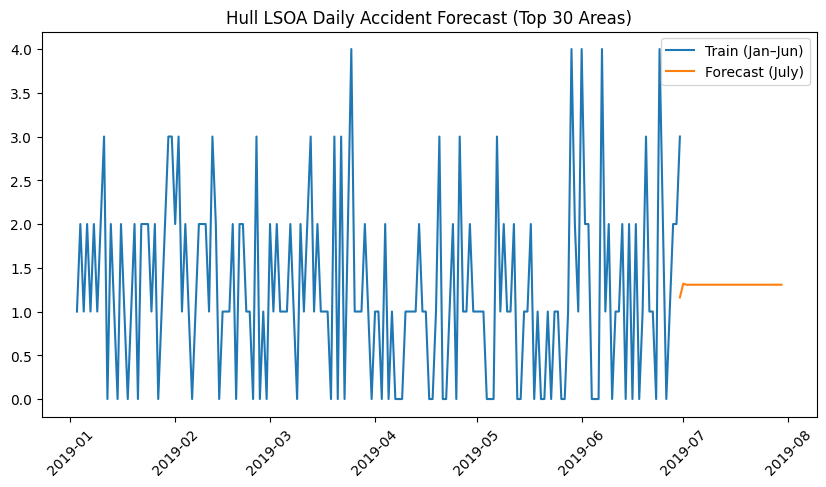

2019-07-01    1.161119
2019-07-02    1.319016
2019-07-03    1.305458
2019-07-04    1.306622
2019-07-05    1.306522
2019-07-06    1.306531
2019-07-07    1.306530
2019-07-08    1.306530
2019-07-09    1.306530
2019-07-10    1.306530
2019-07-11    1.306530
2019-07-12    1.306530
2019-07-13    1.306530
2019-07-14    1.306530
2019-07-15    1.306530
2019-07-16    1.306530
2019-07-17    1.306530
2019-07-18    1.306530
2019-07-19    1.306530
2019-07-20    1.306530
2019-07-21    1.306530
2019-07-22    1.306530
2019-07-23    1.306530
2019-07-24    1.306530
2019-07-25    1.306530
2019-07-26    1.306530
2019-07-27    1.306530
2019-07-28    1.306530
2019-07-29    1.306530
2019-07-30    1.306530
2019-07-31    1.306530
Freq: D, Name: predicted_mean, dtype: float64


In [18]:

# OBJECT CREATION

ts = TimeSeriesAnalysis(accidents)

# QUESTION 6: POLICE FORCE ANALYSIS (3 AREAS)
police_forces = [1, 3, 5]  

results_q6 = ts.run_police_force_analysis(police_forces)

print("\nQ6 RESULTS (RMSE per police force):")
for pf, res in results_q6.items():
    print(f"Police Force {pf}: RMSE = {res['rmse']}")


# QUESTION 7: HULL LSOA FORECASTING

ts = TimeSeriesAnalysis(accidents)

forecast = ts.lsoa_forecasting(hull_code=32.0)

print(forecast)

### Social Network Analysis

Analyzes Facebook data by examining relationships between users, including connections, interactions, and network structure. It focuses on identifying patterns such as central users, communities, and interaction strength within the network.

This helps reveal how information flows and how users are connected within the social graph.

#### Class and functions for Social Network Analysis

This class builds and analyses a Facebook social network using an edge list dataset. It constructs a graph where nodes represent users and edges represent friendships, enabling structural analysis of the network.

It performs three main operations:
- Computes basic network properties such as number of nodes, edges, density, and average degree to understand overall network structure.
- Performs edge centrality analysis using betweenness centrality to identify important connections that act as bridges within the network.
- Applies community detection algorithms (Girvan-Newman and Greedy Modularity) to identify groups of closely connected users within the social graph.

Overall, the class transforms raw social media data into a structured network model for analysing connectivity patterns, influence, and community structure. 

In [19]:

# IMPORT LIBRARIES

import networkx as nx  # for graph analysis
import matplotlib.pyplot as plt  # for plotting
from networkx.algorithms.community import girvan_newman 
from networkx.algorithms.community import greedy_modularity_communities  


# SOCIAL NETWORK ANALYSIS CLASS
class SocialNetworkAnalysis:
    
    def __init__(self, edge_file):
        # Load the graph from edge list file (Facebook dataset)
        self.G = nx.read_edgelist(edge_file, nodetype=int)
    
    
    #  BASIC NETWORK PROPERTIES
    def basic_properties(self):
        # Number of nodes (users)
        num_nodes = self.G.number_of_nodes()
        
        # Number of edges (friendships)
        num_edges = self.G.number_of_edges()
        
        #  how connected is the network 
        density = nx.density(self.G)
        
        # Aaverage number of connections per node
        avg_degree = sum(dict(self.G.degree()).values()) / num_nodes
        
        # Print results
        print(" BASIC NETWORK PROPERTIES ")
        print("Nodes:", num_nodes)
        print("Edges:", num_edges)
        print("Density:", density)
        print("Average Degree:", avg_degree)
        
        # Return values for report use
        return num_nodes, num_edges, density, avg_degree
    
    
    #  EDGE CENTRALITY ANALYSIS
    
    def edge_centrality_analysis(self):
        # Compute edge betweenness centrality importance of edges
        edge_centrality = nx.edge_betweenness_centrality(self.G)
        
        # Extract values only for plotting
        values = list(edge_centrality.values())
        
        # Plot distribution of edge centrality
        plt.figure(figsize=(8,5))
        plt.hist(values, bins=50)
        plt.title("Edge Betweenness Centrality Distribution")
        plt.xlabel("Edge Centrality")
        plt.ylabel("Frequency")
        plt.savefig("Edge Betweenness Centrality Distribution.png", dpi=200, bbox_inches='tight')
        plt.show()
        
      
        return values
    
    
        # COMMUNITY DETECTION
    
    def community_detection(self):

        # LIMIT GRAPH SIZE (CRITICAL)
        G_small = self.G.subgraph(list(self.G.nodes())[:300])
    
    
        # Girvan-Newman (fast for small graph)
        gn_communities = next(girvan_newman(G_small))
        gn_communities = [list(c) for c in gn_communities]
    
        # Greedy modularity (now fast)
        greedy_communities = list(greedy_modularity_communities(G_small))
    
        gn_sizes = [len(c) for c in gn_communities]
        greedy_sizes = [len(c) for c in greedy_communities]
    
        print("\n COMMUNITY DETECTION RESULTS")
        print("Girvan-Newman communities:", len(gn_communities))
        print("Greedy communities:", len(greedy_communities))
    
        print("\nGN sizes:", gn_sizes)
        print("Greedy sizes:", greedy_sizes)
    
        return gn_communities, greedy_communities



### Executing the Function

Runs the defined class methods to load the Facebook network data, compute basic network properties, perform edge centrality analysis, and detect communities within the graph.

This step executes the full social network analysis pipeline to generate results and visual outputs for interpretation.

In [20]:
# EXECUTING THE ANALYSIS

    
    # Create analysis object using dataset file
analysis = SocialNetworkAnalysis("facebook_combined-1.txt")
    
    #  basic properties
analysis.basic_properties()
    

 BASIC NETWORK PROPERTIES 
Nodes: 4039
Edges: 88234
Density: 0.010819963503439287
Average Degree: 43.69101262688784


(4039, 88234, 0.010819963503439287, 43.69101262688784)

In [21]:
analysis.community_detection()           # community detection comparison


 COMMUNITY DETECTION RESULTS
Girvan-Newman communities: 2
Greedy communities: 8

GN sizes: [299, 1]
Greedy sizes: [105, 94, 32, 29, 15, 11, 8, 6]


([[0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128,
   129,
   130,
   131,
   132,
   133,
   134,
   135,
   136,
   137,
   138,
   13

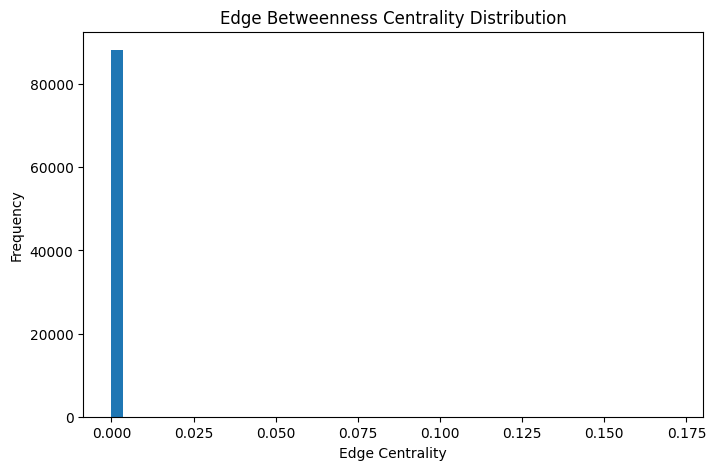

[0.00040049937955461345,
 0.0004923848145417046,
 0.0004287786850298508,
 0.000494007105805077,
 0.0004102707367255275,
 0.0004943238949383351,
 0.00038541192817595303,
 0.0004941910478824526,
 0.00036799034834932996,
 0.00042155934476553373,
 0.0004951720722951225,
 0.0004951720722951225,
 0.00038378055161711246,
 0.0004916192164720352,
 0.0004951720722951225,
 0.00048681365670770943,
 0.0004910670496064318,
 0.0004951720722951225,
 0.0004895878244032402,
 0.0004917922582781589,
 0.0003490742281667195,
 0.0004152807378449189,
 0.0004897151239996462,
 0.0004832051553132059,
 0.0003673549680936626,
 0.00036784255714446886,
 0.00042273172334349564,
 0.0004917973677803083,
 0.0004859359902242319,
 0.0004131537610889293,
 0.0004040990184031447,
 0.0004936310464468869,
 0.0004950494442435388,
 0.0037169145183296847,
 0.0004944363039856201,
 0.0004928995117248797,
 0.0004951720722951225,
 0.00042374533577078965,
 0.0004158392571013088,
 0.00039843135649593616,
 0.000490342477963544,
 0.00049

In [22]:
 analysis.edge_centrality_analysis()     #  edge centrality analysis + plot
    
   
    

### Visualization

In [23]:


class NetworkVisualisations:
    
    def __init__(self, G):
        # Store the graph inside the class
        self.G = G

    
    # NETWORK STRUCTURE VISUALISATION
    
    def plot_network(self):
        pos = nx.spring_layout(self.G, seed=42)  # layout for graph structure

        plt.figure(figsize=(10, 7))
        nx.draw(self.G, pos,
                node_size=10,
                edge_color="gray",
                alpha=0.4)
        plt.title("Facebook Network Structure (Spring Layout)")
        plt.savefig("Facebook_Network_Structure_Spring Layout.png", dpi=200, bbox_inches='tight')
        plt.show()

    
    #  DEGREE DISTRIBUTION
    
    def plot_degree_distribution(self):
        degrees = [d for n, d in self.G.degree()]  # extract node degrees

        plt.figure(figsize=(8,5))
        plt.hist(degrees, bins=50)
        plt.title("Degree Distribution of Facebook Network")
        plt.xlabel("Degree (Number of Connections)")
        plt.ylabel("Frequency")
        plt.savefig("Degree Distribution of Facebook Network.png", dpi=200, bbox_inches='tight')
        plt.show()

    
    #  EDGE CENTRALITY DISTRIBUTION
    
    def plot_edge_centrality(self):
        edge_centrality = nx.edge_betweenness_centrality(self.G)  # compute edge importance

        plt.figure(figsize=(8,5))
        plt.hist(list(edge_centrality.values()), bins=50)
        plt.title("Edge Betweenness Centrality Distribution")
        plt.xlabel("Edge Centrality")
        plt.ylabel("Frequency")
        plt.savefig("Edge Betweenness Centrality Distribution.png", dpi=200, bbox_inches='tight')
        plt.show()

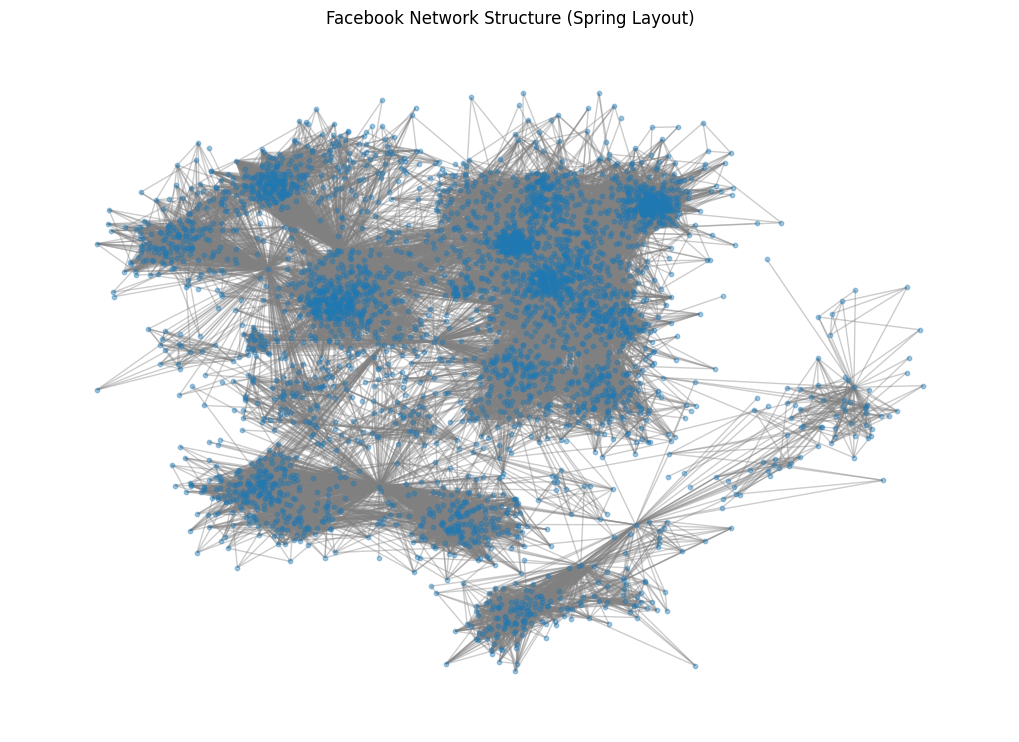

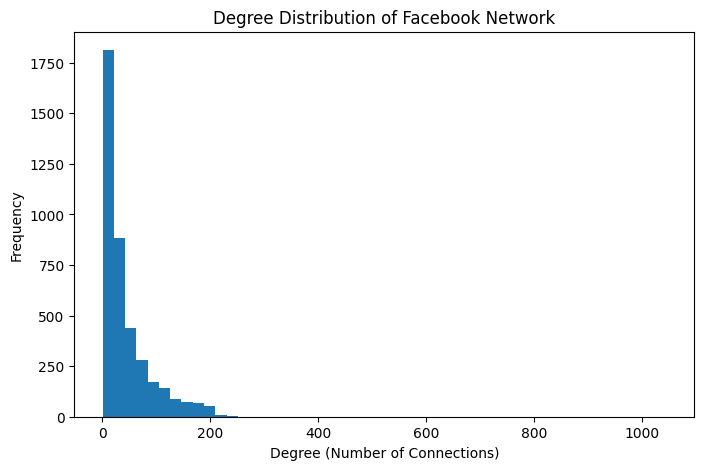

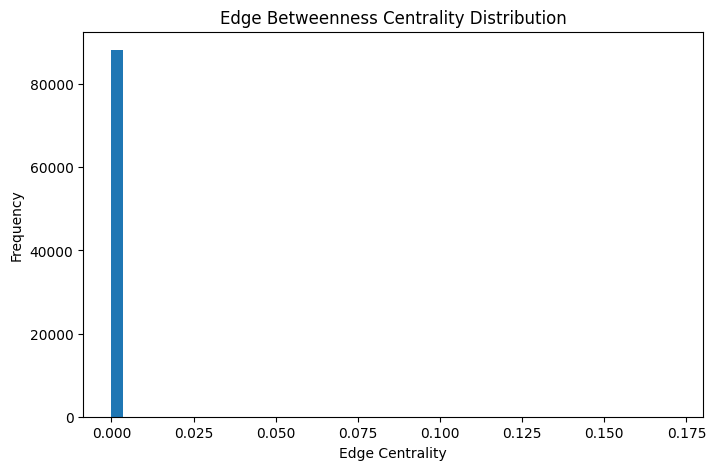

In [25]:
# creating the object 
analysis = SocialNetworkAnalysis("facebook_combined-1.txt")

visuals = NetworkVisualisations(analysis.G)


# run visuals
visuals.plot_network()
visuals.plot_degree_distribution()
visuals.plot_edge_centrality()